<a href="https://colab.research.google.com/github/Melaan99/Data-Science-Pipelines/blob/main/Lab_Redes_Neuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Redes Neuronales en Inteligencia Artificial

In [ ]:
# Importar las librerías necesarias
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


### Simulación de un modelo básico para predicción basada en datos genómicos

#### **1. Carga y Preprocesamiento de Datos**

In [ ]:
# Dataset relacionado con características biomédicas (Pima Indians Diabetes)
# https://github.com/jbrownlee/Datasets/tree/master
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
column_names = ['Embarazos', 'Glucosa', 'Presión arterial', 'Pliegue cutáneo', 'Insulina', 'Índice de masa corporal', 'Historial', 'Edad', 'Diagnóstico']
data = pd.read_csv(url, header=None, names=column_names)# Inspección inicial de los datos
print("Vista previa del dataset:")
print(data.head())

# Verificar valores faltantes
data.info()

# Estadísticas descriptivas
data.describe()

Vista previa del dataset:
   Embarazos  Glucosa  Presión arterial  Pliegue cutáneo  Insulina  \
0          6      148                72               35         0   
1          1       85                66               29         0   
2          8      183                64                0         0   
3          1       89                66               23        94   
4          0      137                40               35       168   

   Índice de masa corporal  Historial  Edad  Diagnóstico  
0                     33.6      0.627    50            1  
1                     26.6      0.351    31            0  
2                     23.3      0.672    32            1  
3                     28.1      0.167    21            0  
4                     43.1      2.288    33            1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   -----------

,Embarazos,Glucosa,Presión arterial,Pliegue cutáneo,Insulina,Índice de masa corporal,Historial,Edad,Diagnóstico
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#### **2. Análisis Exploratorio de Datos (EDA)**

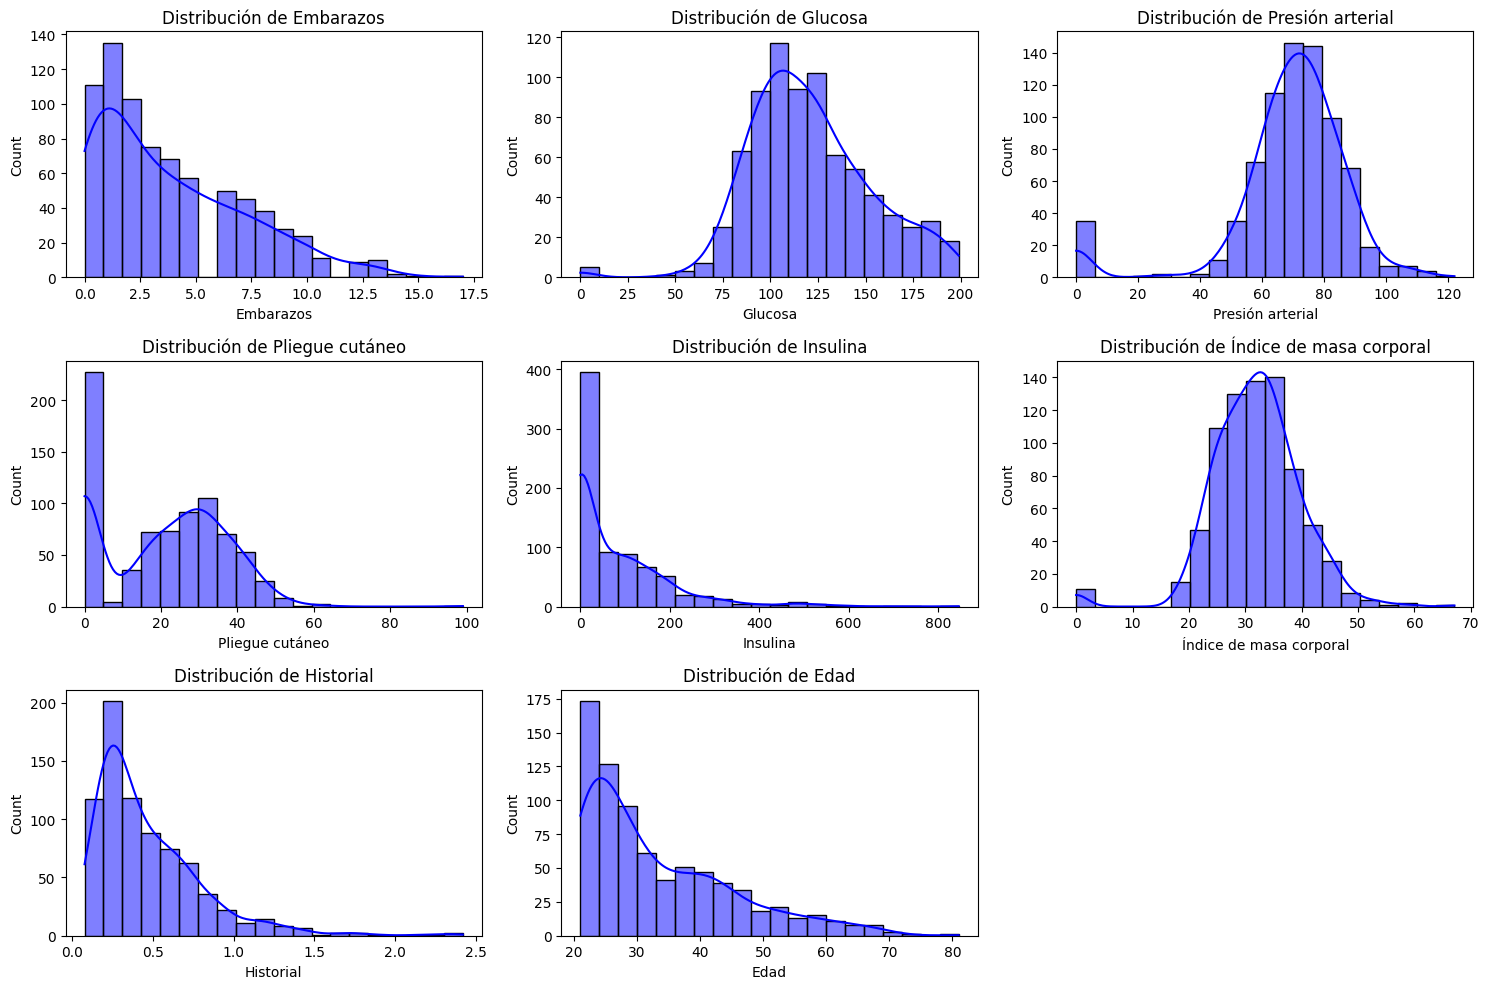

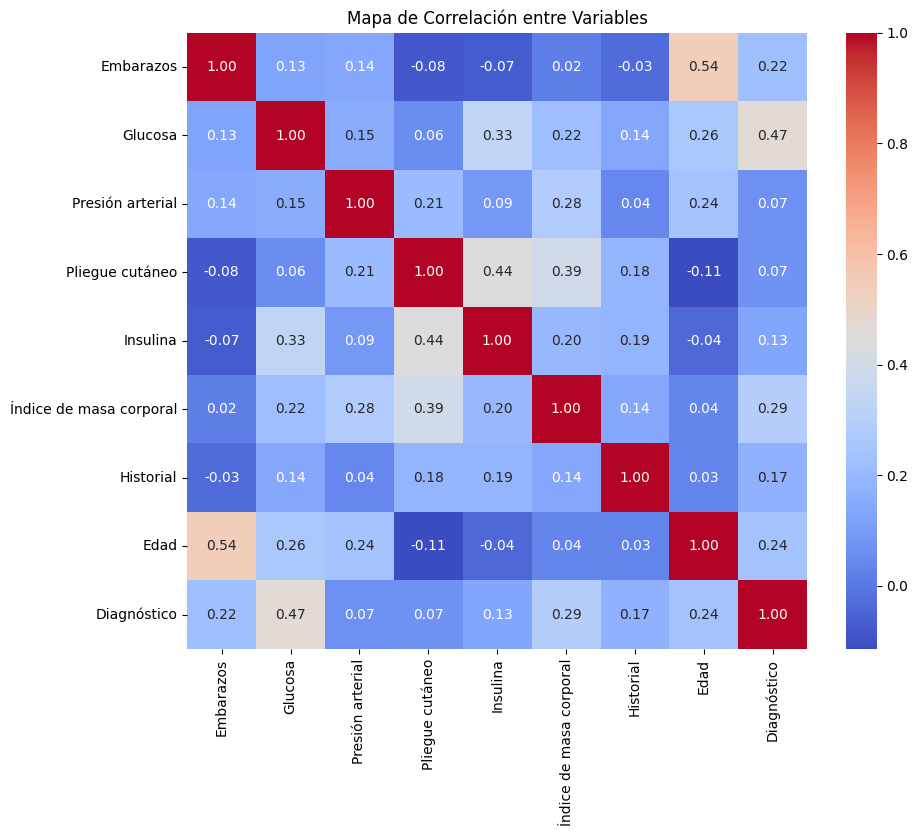

In [ ]:
# Visualizar la distribución de las características
plt.figure(figsize=(15, 10))
for i, column in enumerate(data.columns[:-1]):
    plt.subplot(3, 3, i+1)
    sns.histplot(data[column], kde=True, bins=20, color='blue')
    plt.title(f'Distribución de {column}')
plt.tight_layout()
plt.show()

# Correlación entre características
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Correlación entre Variables')
plt.show()

### **3. Preprocesamiento de Datos**

In [ ]:
# Separar características y etiquetas
X = data.iloc[:, :-1]
y = data['Diagnóstico']

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalado de características
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### **4. Selección de Características**

In [ ]:
# Usar la correlación para seleccionar las características más relevantes
correlation = data.corr()['Diagnóstico'][:-1]
selected_features = correlation[abs(correlation) > 0.2].index.tolist()
print("Características seleccionadas:", selected_features)

X_train_selected = pd.DataFrame(X_train, columns=data.columns[:-1])[selected_features].values
X_test_selected = pd.DataFrame(X_test, columns=data.columns[:-1])[selected_features].values

Características seleccionadas: ['Embarazos', 'Glucosa', 'Índice de masa corporal', 'Edad']


#### **5. Creación e Implementación del Modelo**

1. **Estructura del modelo:**
   - **Capa oculta 1:** 16 neuronas con función de activación ReLU.
   - **Dropout:** Regularización que apaga aleatoriamente algunas neuronas durante el entrenamiento para evitar sobreajuste.
   - **Capa oculta 2:** 8 neuronas con activación ReLU.
   - **Capa de salida:** 1 neurona con activación sigmoide para clasificar los datos en dos categorías.
2. **Compilación:** Se usa Adam como optimizador y entropía cruzada como función de pérdida, adecuada para clasificación binaria.
3. **Entrenamiento:** Se entrena el modelo durante 50 épocas, evaluando su rendimiento en los conjuntos de entrenamiento y validación.

In [ ]:
# Crear un modelo de red neuronal
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_selected.shape[1],)),
    Dropout(0.3),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(X_train_selected, y_train, epochs=50, batch_size=10, validation_data=(X_test_selected, y_test), verbose=1)

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4605 - loss: 0.7052 - val_accuracy: 0.6753 - val_loss: 0.6619
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6480 - loss: 0.6566 - val_accuracy: 0.7403 - val_loss: 0.6197
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6798 - loss: 0.6207 - val_accuracy: 0.7403 - val_loss: 0.5808
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7116 - loss: 0.5717 - val_accuracy: 0.7792 - val_loss: 0.5489
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7495 - loss: 0.5429 - val_accuracy: 0.7792 - val_loss: 0.5318
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7472 - loss: 0.4990 - val_accuracy: 0.7792 - val_loss: 0.5195
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7312 - loss: 0.5164 - val_accuracy: 0.7532 - val_loss: 0.5134
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7609 - loss: 0.4839 - val_accuracy: 0.7597 - val_loss:

#### **6. Evaluación del Modelo**

1. **Gráficas de entrenamiento:**
   - **Precisión:** Muestra cómo mejora la capacidad del modelo para clasificar correctamente durante el entrenamiento.
   - **Pérdida:** Indica qué tan bien se ajusta el modelo a los datos; valores más bajos son mejores.
2. **Reporte de clasificación:** Proporciona métricas como precisión, recall y F1-score para evaluar el desempeño del modelo en el conjunto de prueba.
3. **Matriz de confusión:** Visualiza los aciertos y errores de las predicciones, facilitando la identificación de áreas de mejora.

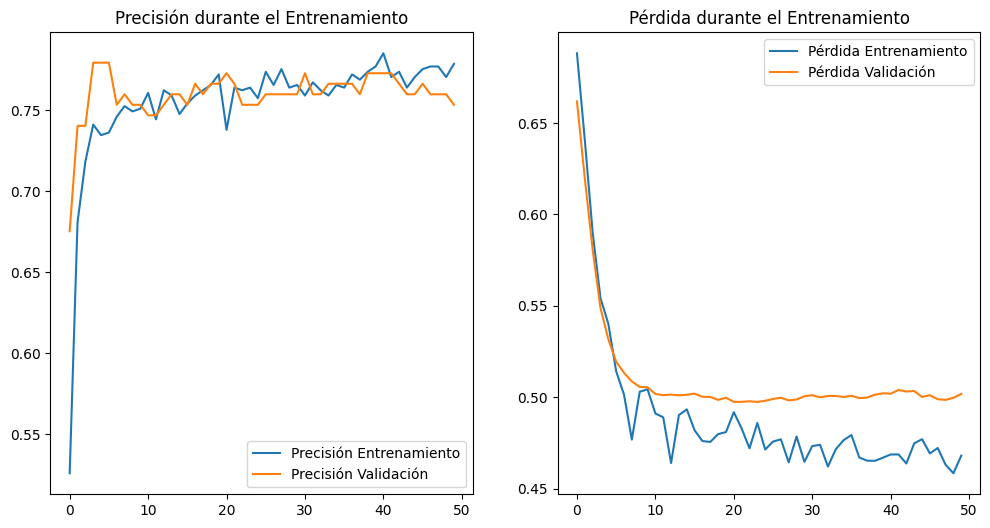

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.80      0.82      0.81        99
           1       0.66      0.64      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



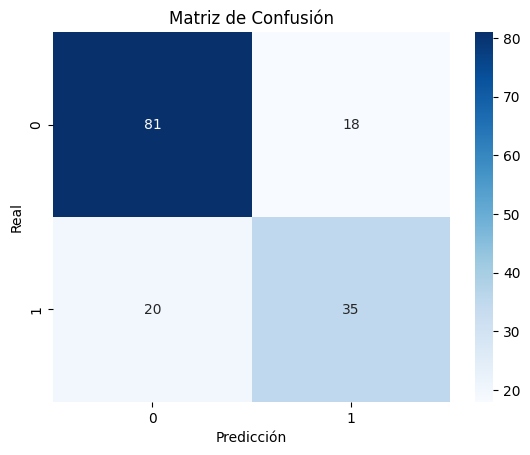

In [ ]:
# Métricas de entrenamiento
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Precisión Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión Validación')
plt.legend()
plt.title('Precisión durante el Entrenamiento')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida Validación')
plt.legend()
plt.title('Pérdida durante el Entrenamiento')
plt.show()

# Predicciones y Métricas
y_pred = (model.predict(X_test_selected) > 0.5).astype(int)
print("Reporte de Clasificación:\n", classification_report(y_test, y_pred))

# Matriz de Confusión
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()
